# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [ ]:
import kagglehub
import os
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [ ]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [ ]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [ ]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



How many Pokémon are in the dataset? (2 pts)


In [ ]:
df.shape[0]

800

800 Pokemons!


List all columns available (3 pts)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


- Name
- Type 1
- Type 2
- Total
- HP
- Attack
- Defense
- Sp. Atk
- Sp. Def
- Speed
- Generation
- Legendary

## 2: Select Features & Clean the Data (8 pts)

Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed). (3 pts)

In [ ]:
features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
data_features = df[features]
data_features.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,80,100,123,122,120,80
4,39,52,43,60,50,65


Are there any missing values? (2 pts)

In [ ]:
df.isna().sum()

,0
#,0
Name,0
Type 1,0
Type 2,386
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


If missing values exist, describe how you handled them (3 pts)

In [ ]:
# After running a command that counts all the null values in each column,
# I replaced the null values with "None". As expected,
# Type 2 has a lot of null values, because not all pokemons are dual-type, etc.

df["Type 2"] = df["Type 2"].fillna("None")
print(df["Type 2"].value_counts())
df.info()

Type 2
None        386
Flying       97
Ground       35
Poison       34
Psychic      33
Fighting     26
Grass        25
Fairy        23
Steel        22
Dark         20
Dragon       18
Ice          14
Rock         14
Water        14
Ghost        14
Fire         12
Electric      6
Normal        4
Bug           3
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      800 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64

# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [ ]:
scaler=StandardScaler()
scaled_features=scaler.fit_transform(data_features)
scaled_df=pd.DataFrame(scaled_features, columns=data_features.columns)
scaled_df.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,-0.950626,-0.924906,-0.797154,-0.239130,-0.248189,-0.801503
1,-0.362822,-0.524130,-0.347917,0.219560,0.291156,-0.285015
2,0.420917,0.092448,0.293849,0.831146,1.010283,0.403635
3,0.420917,0.647369,1.577381,1.503891,1.729409,0.403635
4,-1.185748,-0.832419,-0.989683,-0.392027,-0.787533,-0.112853


## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

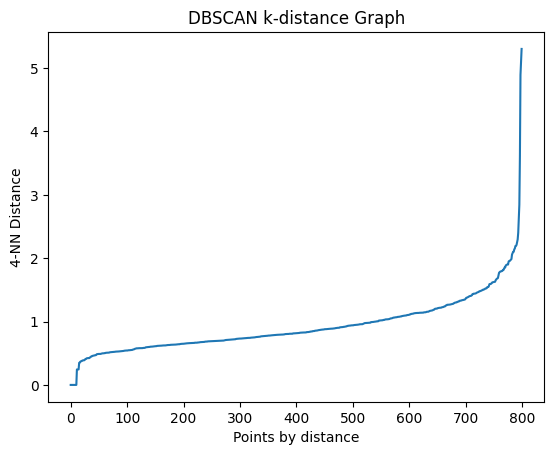

In [ ]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(scaled_df)
distances, _ = neighbors.kneighbors(scaled_df)
k_distances = np.sort(distances[:, 3])
plt.plot(k_distances)
plt.xlabel('Points by distance')
plt.ylabel('4-NN Distance')
plt.title('DBSCAN k-distance Graph')
plt.show()

What is your chosen eps based on the "elbow"? (2 pts)

In [ ]:
y = k_distances
x = np.arange(len(y))
p1 = np.array([x[0], y[0]])
p2 = np.array([x[-1], y[-1]])

distances = np.abs(
    np.cross(p2 - p1, p1 - np.vstack((x, y)).T)
) / np.linalg.norm(p2 - p1)
elbow_index = np.argmax(distances)
optimal_eps = y[elbow_index]
print("Optimal eps:", optimal_eps)

if 1.4 <= optimal_eps <= 2.0:
    print("Accepted eps:", optimal_eps)
else:
    print("Fallback to visual range")

Optimal eps: 1.5248638064269173
Accepted eps: 1.5248638064269173


/tmp/ipython-input-3810512397.py:7: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  np.cross(p2 - p1, p1 - np.vstack((x, y)).T)


eps = 1.5

One-sentence explanation of your reasoning (2 pts)

I chose eps = 1.5 because it’s at the “elbow” of the 4-NN distance graph, basically where distances start rising fast, so it helps separate tight Pokémon groups from outliers.

## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


How many clusters did DBSCAN find? (4 pts)

In [ ]:
min_samples = [4, 6, 8, 10, 12, 15]
for min_sample in min_samples:
    db = DBSCAN(eps=1.5, min_samples=min_sample, metric="euclidean")
    db.fit(scaled_df)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"min_samples={min_sample}: clusters={n_clusters}")

min_samples=4: clusters=1
min_samples=6: clusters=2
min_samples=8: clusters=1
min_samples=10: clusters=1
min_samples=12: clusters=1
min_samples=15: clusters=1


How many Pokémon were labeled as noise? (4 pts)

In [ ]:
db = DBSCAN(eps=1.5, min_samples=6, metric="euclidean")
db.fit(scaled_df)
labels = db.labels_
n_noise = list(labels).count(-1)
print(f"Noise Pokémons = {n_noise}")

Noise Pokémons = 44


Show the unique labels output by DBSCAN (2 pts)

In [ ]:
print("Unique Labels:", np.unique(labels))

Unique Labels: [-1  0  1]


## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)

In [ ]:
df['cluster'] = db.labels_

Show the first 10 rows including the cluster label (4 pts)

In [ ]:
df.head(10)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,0
4,4,Charmander,Fire,None,309,39,52,43,60,50,65,1,False,0
5,5,Charmeleon,Fire,None,405,58,64,58,80,65,80,1,False,0
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False,0
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False,0
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False,0
9,7,Squirtle,Water,None,314,44,48,65,50,64,43,1,False,0


## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [ ]:
df["cluster"].value_counts()

,count
cluster,
0,750
-1,44
1,6


What are the average Attack, Defense, and Speed? (4 pts)


In [ ]:
df.groupby("cluster")[["Attack", "Defense", "Speed"]].mean()

,Attack,Defense,Speed
cluster,,,
-1,104.545455,88.909091,73.886364
0,77.665333,72.318667,68.068000
1,58.666667,153.833333,53.333333


Compare the clusters: What differences do you notice? (4 pts)

In [ ]:
  # some are fast and hit hard,
  # others are tanky and slow,
  # and some are more balanced overall

## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [ ]:
df[df["cluster"] == -1]
df[df["cluster"] == -1]["Name"]

,Name
19,BeedrillMega Beedrill
44,Jigglypuff
71,AlakazamMega Alakazam
87,SlowbroMega Slowbro
103,Onix
121,Chansey
155,Snorlax
163,MewtwoMega Mewtwo X
164,MewtwoMega Mewtwo Y
196,AmpharosMega Ampharos


Are many of them legendary? (3 pts)

In [46]:
# All outliers
outliers = df[df["cluster"] == -1]

# Legendary outliers
legendary_outliers = outliers[outliers["Legendary"] == True]

print(legendary_outliers[['Name', 'Legendary', 'cluster']])

num_legendary = legendary_outliers.shape[0]
num_outliers = outliers.shape[0]

percentage = (num_legendary / num_outliers) * 100 if num_outliers > 0 else 0

print("Number of outliers:", len(outliers))
print(f"Number of legendary outliers: {num_legendary}")
print(f"Percentage of legendary Pokémon in outliers: {percentage:.2f}%")


                      Name  Legendary  cluster
163    MewtwoMega Mewtwo X       True       -1
164    MewtwoMega Mewtwo Y       True       -1
269                  Lugia       True       -1
414               Regirock       True       -1
415                 Regice       True       -1
422    KyogrePrimal Kyogre       True       -1
424  GroudonPrimal Groudon       True       -1
426  RayquazaMega Rayquaza       True       -1
428     DeoxysNormal Forme       True       -1
429     DeoxysAttack Forme       True       -1
431      DeoxysSpeed Forme       True       -1
544  GiratinaAltered Forme       True       -1
796    DiancieMega Diancie       True       -1
798     HoopaHoopa Unbound       True       -1
Number of outliers: 44
Number of legendary outliers: 14
Percentage of legendary Pokémon in outliers: 31.82%


31.82% of the outliers are legendary Pokémon, showing that a notable portion of the outlier group consists of legendaries.

Explain why DBSCAN might classify them as outliers (3 pts)


In [49]:
# DBSCAN treats them as outliers
# because legendary Pokémon usually
# have extreme stats compared to most Pokémon.
# Since they don’t sit in dense clusters,
# they don’t meet the neighbor requirement
# and get labeled as noise.

## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:


What types of Pokémon grouped together (5 pts)

In [50]:
types_long = pd.concat([
    df[["cluster", "Type 1"]].rename(columns={"Type 1": "Type"}),
    df[["cluster", "Type 2"]].rename(columns={"Type 2": "Type"})
]).dropna()

types_no_none_values = types_long[types_long["Type"] != "None"]
types_no_none_values.groupby(["cluster", "Type"]).size().sort_values(ascending=False)

cluster  Type    
 0       Water       121
         Flying       98
         Normal       95
         Grass        94
         Psychic      77
         Bug          68
         Ground       63
         Fire         61
         Poison       61
         Dark         50
         Rock         50
         Fighting     49
         Electric     49
         Dragon       47
         Steel        42
         Ghost        41
         Fairy        37
         Ice          35
-1       Psychic      12
         Normal        7
         Rock          5
         Water         5
         Bug           4
         Fighting      4
         Ghost         4
         Ground        4
 1       Steel         4
         Rock          3
-1       Ice           3
         Fire          3
         Dragon        3
         Steel         3
         Flying        3
         Fairy         2
         Electric      1
         Dark          1
         Poison        1
         Grass         1
 1       Fairy         1
         Psychic       1
         Ghost         1
dtype: int64

Whether the clusters make intuitive sense (10 pts)

In [53]:
# I believe so, yep, the clusters mostly make sense.
# Big types like Water, Normal, and Flying group together bc there are lots of them.
# Rare types like Steel or Fairy stay in small groups.
# Common Pokémon stick together, weird ones are outliers.


What the noise points reveal about DBSCAN (5 pts)


In [52]:
# Noise points are the Pokémon that don't fit anywhere.
# Many Psychic, Ice, or rare types show up here.
# DBSCAN flags them bc they don't have many neighbors—like a lone Mewtwo among Magikarp.
# These are the standouts.

What stat patterns you discovered (5 pts)

In [51]:
# Some clusters have fast attackers, some are slow tanks, and some are balanced.
# Legendary or rare Pokémon often become outliers because their stats are way higher than normal.
# Common types like Water or Normal are more average and stay in big groups.
# Stats decide who hangs with who.